In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import os
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

from baseband_tasks.io import hdf5
from baseband_tasks.functions import Square
from baseband_tasks.dm import DispersionMeasure

import tools.tools as tools
import tools.correlation as correlation

In [3]:
DM = 56.7185
dm = DispersionMeasure(DM)
blur = 16

data_path = "../data/MPs_zipped/"
files = os.listdir(data_path)
# files = [f for f in files if f.endswith('.h5')]
files = [os.path.join(data_path, f) for f in files]

# define sn to be the number after "SN-" and before ".hdf5" in filename (files)
sns = np.zeros_like(files, dtype=float)
times = np.zeros_like(files, dtype=float)
for i, file in enumerate(files):
    sn_start = file.find('SN-') + len('SN-')
    sn_end = file.find('.hdf5')
    sn = float(file[sn_start:sn_end])
    sns[i] = sn
    time_start = file.find('MJD-') + len('MJD-')
    time_end = file.find('_SN')
    time = float(file[time_start:time_end])
    times[i] = time

fs = np.array([hdf5.open(f, 'r') for f in files])

great_ts = [60631.0849231004, 60631.095014371196, 60631.103663024645]
great_ts = np.array([60631.0849231004, 60631.09329920986, 60631.095014371196,
                     60631.10117956385, 60631.103663024645])
num_peaks_arr = np.array([4, 3, 3, 4, 3])
great_ts_idx = [np.argmin(np.abs(times - t)) for t in great_ts]
print(great_ts_idx)

high_sns = np.where(sns > 20)[0]
print(files)
fs = fs[great_ts_idx]

sample_f = fs[0]
print(sample_f.sample_rate)
time_step = (1/sample_f.sample_rate).to(u.ms)
base_ts = np.linspace(0, sample_f.shape[0] * time_step, sample_f.shape[0]).to(u.ms)

[np.int64(33), np.int64(84), np.int64(41), np.int64(47), np.int64(59)]
['../data/MPs_zipped/MP_MJD-60631.093200_SN-8.59.hdf5', '../data/MPs_zipped/MP_MJD-60631.102655_SN-25.79.hdf5', '../data/MPs_zipped/MP_MJD-60631.101103_SN-22.57.hdf5', '../data/MPs_zipped/MP_MJD-60631.095910_SN-13.49.hdf5', '../data/MPs_zipped/MP_MJD-60631.096340_SN-8.61.hdf5', '../data/MPs_zipped/MP_MJD-60631.104933_SN-8.54.hdf5', '../data/MPs_zipped/MP_MJD-60631.097613_SN-8.40.hdf5', '../data/MPs_zipped/MP_MJD-60631.093737_SN-9.09.hdf5', '../data/MPs_zipped/MP_MJD-60631.102006_SN-7.97.hdf5', '../data/MPs_zipped/MP_MJD-60631.103594_SN-12.52.hdf5', '../data/MPs_zipped/MP_MJD-60631.086798_SN-8.80.hdf5', '../data/MPs_zipped/MP_MJD-60631.084851_SN-6.32.hdf5', '../data/MPs_zipped/MP_MJD-60631.083793_SN-12.85.hdf5', '../data/MPs_zipped/MP_MJD-60631.103868_SN-7.19.hdf5', '../data/MPs_zipped/MP_MJD-60631.101886_SN-6.18.hdf5', '../data/MPs_zipped/MP_MJD-60631.095814_SN-9.15.hdf5', '../data/MPs_zipped/MP_MJD-60631.095412_SN-

Trying different blurs to find best fit for peak frequency evolution...
  - Average R2 of blur=8 parabola fits: 0.439
Using results for blur = 8
Trying different blurs to find best fit for peak frequency evolution...
  - Average R2 of blur=8 parabola fits: 0.275
  - Average R2 of blur=16 parabola fits: 0.370
Using results for blur = 16
Trying different blurs to find best fit for peak frequency evolution...
  - Average R2 of blur=8 parabola fits: 0.316
  - Average R2 of blur=16 parabola fits: 0.391
Using results for blur = 16
Trying different blurs to find best fit for peak frequency evolution...
  - Average R2 of blur=8 parabola fits: 0.236
  - Average R2 of blur=16 parabola fits: 0.425
Using results for blur = 16
Trying different blurs to find best fit for peak frequency evolution...
  - Average R2 of blur=8 parabola fits: 0.329
  - Average R2 of blur=16 parabola fits: 0.354
Using results for blur = 16


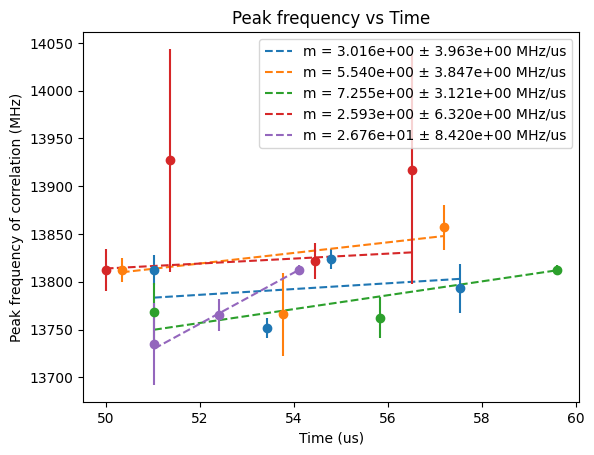

In [ ]:
blurs = [8, 16, 32]

correlations = {}
freqs_blur = {}
peak_times = {}
fn = 0
f = fs[fn]

for fn, f in enumerate(fs):
    correlation.get_correlation_peak_evolution(f, num_peaks_arr[fn], f.header0['frequency'], base_ts, blurs=blurs, plot=True, verbose=1)
plt.show()